<a href="https://colab.research.google.com/github/zpsheldon/meg-neural-decoding/blob/main/phoneme-classification-naive-baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
# Install additional depdendencies
%pip install -q lightning torchmetrics scikit-learn plotly ipywidgets pnpl

# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.3 MB/s eta 0:00:00


In [2]:
from pnpl.datasets import LibriBrainPhoneme
from torch.utils.data import DataLoader
import pandas as pd
import random
import numpy as np
import torch
import platform

## Load one event file and explore phonemes

In [4]:
train_dataset = LibriBrainPhoneme(
  data_path=f"{base_path}/data/",
  include_run_keys = [("0",1,"Sherlock1","1")],
  tmin=0.0,
  tmax = 0.5
)
f = f"{base_path}/data/Sherlock1/derivatives/events/sub-0_ses-1_task-Sherlock1_run-1_events.tsv"
data = pd.read_csv(f, sep='\t')
data

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(…)-0_ses-1_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/342M [00:00<?, ?B/s]

Done!
calculated stats for:  ('0', 1, 'Sherlock1', '1')


,idx,wavile,kind,segment,sentenceidx,wordidx,phonemeidx,timemeg,timeds,timechapter,timesentence,duration
0,1,segments/,silence,NaN,NaN,NaN,NaN,28.772,28.772,0.000,NaN,1.188
1,2,segments/,word,A,0.0,0.0,NaN,30.086,30.084,1.298,0.11,0.100
2,3,segments/,phoneme,ah_S,0.0,0.0,0.0,30.086,30.084,1.298,0.11,0.100
3,4,segments/,word,Study,0.0,1.0,NaN,30.186,30.184,1.398,0.21,0.370
4,5,segments/,phoneme,s_B,0.0,1.0,0.0,30.186,30.184,1.398,0.21,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...
12801,12802,segments/,phoneme,er_E,187.0,2.0,4.0,1098.278,1098.276,1064.404,0.79,0.060
12802,12803,segments/,word,one,187.0,3.0,NaN,1098.338,1098.336,1064.464,0.85,0.340
12803,12804,segments/,phoneme,w_B,187.0,3.0,0.0,1098.338,1098.336,1064.464,0.85,0.120
12804,12805,segments/,phoneme,ah_I,187.0,3.0,1.0,1098.458,1098.460,1064.584,0.97,0.100


In [7]:
data[data["kind"]=="phoneme"].groupby(by="segment",as_index=False).count()

,segment,idx,wavile,kind,sentenceidx,wordidx,phonemeidx,timemeg,timeds,timechapter,timesentence,duration
0,aa_B,25,25,25,25,25,25,25,25,25,25,25
1,aa_E,2,2,2,2,2,2,2,2,2,2,2
2,aa_I,94,94,94,94,94,94,94,94,94,94,94
3,ae_B,113,113,113,113,113,113,113,113,113,113,113
4,ae_I,198,198,198,198,198,198,198,198,198,198,198
...,...,...,...,...,...,...,...,...,...,...,...,...
105,y_B,59,59,59,59,59,59,59,59,59,59,59
106,y_I,28,28,28,28,28,28,28,28,28,28,28
107,z_E,245,245,245,245,245,245,245,245,245,245,245
108,z_I,43,43,43,43,43,43,43,43,43,43,43


## Load all event data

In [3]:
num_books = 7
num_chapters = [9, 12, 12, 12, 15, 14, 14]

In [11]:
# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

run_keys = [("0",str(i),f"Sherlock{j}","1") for j in range(1,8) for i in range(1, num_chapters[j-1])]
all_data = LibriBrainPhoneme(
  data_path=f"{base_path}/data/",
  include_run_keys = run_keys,
  tmin=0.0,
  tmax=0.5,
  preload_files = True
)

(…)-0_ses-8_task-Sherlock3_run-1_events.tsv: 0.00B [00:00, ?B/s]

(…)-0_ses-3_task-Sherlock7_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock7/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/669M [00:00<?, ?B/s]

Sherlock6/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.01G [00:00<?, ?B/s]

(…)0_ses-13_task-Sherlock6_run-1_events.tsv: 0.00B [00:00, ?B/s]

...

Sherlock3/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.05G [00:00<?, ?B/s]

Sherlock3/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.13G [00:00<?, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/330M [00:00<?, ?B/s]

(…)-0_ses-1_task-Sherlock6_run-1_events.tsv: 0.00B [00:00, ?B/s]

Done!
calculated stats for:  ('0', '2', 'Sherlock1', '1')
calculated stats for:  ('0', '3', 'Sherlock1', '1')
calculated stats for:  ('0', '4', 'Sherlock1', '1')
calculated stats for:  ('0', '5', 'Sherlock1', '1')
calculated stats for:  ('0', '6', 'Sherlock1', '1')
calculated stats for:  ('0', '7', 'Sherlock1', '1')
calculated stats for:  ('0', '8', 'Sherlock1', '1')
calculated stats for:  ('0', '1', 'Sherlock2', '1')
calculated stats for:  ('0', '2', 'Sherlock2', '1')
calculated stats for:  ('0', '3', 'Sherlock2', '1')
calculated stats for:  ('0', '4', 'Sherlock2', '1')
calculated stats for:  ('0', '5', 'Sherlock2', '1')
calculated stats for:  ('0', '6', 'Sherlock2', '1')
calculated stats for:  ('0', '7', 'Sherlock2', '1')
calculated stats for:  ('0', '8', 'Sherlock2', '1')
calculated stats for:  ('0', '9', 'Sherlock2', '1')
calculated stats for:  ('0', '10', 'Sherlock2', '1')
calculated stats for:  ('0', '11', 'Sherlock2', '1')
calculated stats for:  ('0', '1', 'Sherlock3', '1')
calc

## Load tsv event files and calculate class balances

In [14]:
tsv_file_paths = [f"{base_path}/data/Sherlock{j}/derivatives/events/sub-0_ses-{i}_task-Sherlock{j}_run-1_events.tsv" for j in range(1,8) for i in range(1, num_chapters[j-1])]

phoneme_n = {}
for f in tsv_file_paths:
  data = pd.read_csv(f, sep='\t')
  group_df = data[data["kind"]=="phoneme"].groupby(by="segment",as_index=False).count()
  for idx,row in group_df.iterrows():
    curr_phoneme = row.segment
    curr_n = row.idx
    if curr_phoneme not in phoneme_n:
      phoneme_n[curr_phoneme] = curr_n
    else:
      phoneme_n[curr_phoneme] = phoneme_n[curr_phoneme]+curr_n

In [15]:
phoneme_n

{'aa_B': 2829,
 'aa_E': 63,
 'aa_I': 16680,
 'ae_B': 12779,
 'ae_I': 27379,
 'ah_B': 33189,
 'ah_E': 24344,
 'ah_I': 76208,
 'ah_S': 10331,
 'ao_B': 5404,
 'ao_E': 560,
 'ao_I': 14915,
 'aw_B': 2451,
 'aw_E': 1703,
 'aw_I': 6190,
 'ay_B': 1339,
 'ay_E': 6140,
 'ay_I': 13870,
 'ay_S': 11336,
 'b_B': 18313,
 'b_E': 292,
 'b_I': 5838,
 'ch_B': 1403,
 'ch_E': 4704,
 'ch_I': 2271,
 'd_B': 12173,
 'd_E': 46534,
 'd_I': 11382,
 'dh_B': 42677,
 'dh_E': 473,
 'dh_I': 2560,
 'eh_B': 6335,
 'eh_I': 36960,
 'er_B': 573,
 'er_E': 20744,
 'er_I': 16835,
 'er_S': 796,
 'ey_B': 652,
 'ey_E': 4456,
 'ey_I': 15378,
 'ey_S': 389,
 'f_B': 15471,
 'f_E': 4202,
 'f_I': 5926,
 'g_B': 5926,
 'g_E': 418,
 'g_I': 4406,
 'hh_B': 38118,
 'hh_I': 725,
 'ih_B': 29320,
 'ih_E': 5150,
 'ih_I': 61133,
 'iy_B': 1093,
 'iy_E': 34793,
 'iy_I': 15983,
 'jh_B': 1803,
 'jh_E': 1677,
 'jh_I': 2211,
 'k_B': 15869,
 'k_E': 7822,
 'k_I': 15517,
 'l_B': 10301,
 'l_E': 14946,
 'l_I': 26143,
 'm_B': 20646,
 'm_E': 12563,
 'm_I': 1

In [16]:
len(phoneme_n)

120

In [17]:
import pickle
with open("phoneme_n.pkl", "wb") as file:
    pickle.dump(phoneme_n, file)

In [ ]:
from sklearn.metrics import f1_score

most_freq_phon =
y_preds = np.ones(len(y_true))*most_freq_phon

f1_macro = f1_score(y_true, y_preds, average="macro")
f1_overall = f1_score(y_true, y_preds)
print(f"Macro: {f1_macro}")
print(f"F1: {f1_overall}")

Macro: 0.433718558803535
F1: 0.86743711760707
Balanced Acc: 0.5
ROC AUC: 0.5


In [ ]:
print(len(all_labels))

6664


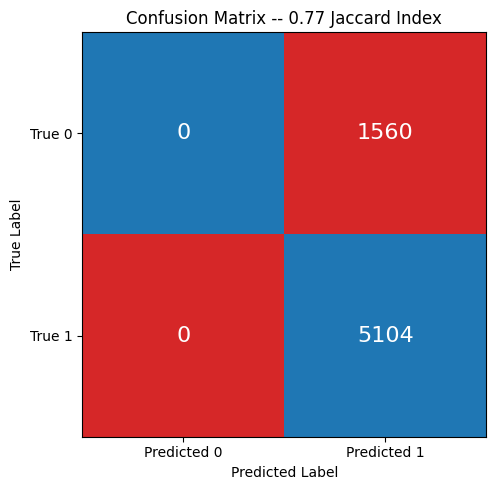

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap
from sklearn.metrics import jaccard_score


def plot_confusion_matrix_1s_0s(labels, preds):
    labels = labels.flatten()
    preds = preds.flatten()

    # Compute confusion matrix
    cm = confusion_matrix(labels, preds, labels=[0, 1])

    # Create a binary matrix indicating correct predictions (diagonals) as 1 and incorrect as 0
    cell_type = np.zeros_like(cm)
    for i in range(cm.shape[0]):
        cell_type[i, i] = 1

    # Define a custom colormap: 0 -> red (incorrect), 1 -> blue (correct)
    cmap = ListedColormap(['tab:red', 'tab:blue'])

    # Plot using matplotlib's imshow
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cell_type, cmap=cmap, vmin=-0.5, vmax=1.5)

    # Overlay the confusion matrix numbers on top of the colored cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha='center', va='center', color='white', fontsize=16)

    iou = jaccard_score(y_true, y_preds, average="binary")

    # Set tick labels
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(["Predicted 0", "Predicted 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix -- {np.round(iou,2)} Jaccard Index")
    fig.tight_layout()

    return fig

# Use the provided function to plot the confusion matrix
fig = plot_confusion_matrix_1s_0s(y_true, y_preds)

# Display the plot
plt.show()